# Part 2B — ANN Comparison + Improved CNN (Experiments A & B)
**Unit:** CIS143-6 Applications of AI  
> Run after `part1_baseline.ipynb` and `part2a_data_segmentation.ipynb`.
> Loads baseline model from Google Drive for comparison.

## 0. Setup & Load Baseline

In [1]:
import os, random, shutil, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = Path('/content/drive/MyDrive/brain_tumour_mri')
DATA_DIR = Path('/content/brain_tumour_data')

if not DATA_DIR.exists():
    shutil.copytree(DRIVE_DIR / 'dataset', DATA_DIR)
    print('Dataset restored from Drive.')

TRAIN_DIR = DATA_DIR / 'Training'
CLASSES = ['glioma', 'meningioma', 'notumor', 'pituitary']
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

Mounted at /content/drive
Dataset restored from Drive.


In [3]:
# Identical split to Part 1 (same random_state)
records = []
for cls in CLASSES:
    for img_path in (TRAIN_DIR / cls).glob('*.jpg'):
        records.append({'filepath': str(img_path), 'label': cls})

df = pd.DataFrame(records).sample(frac=1, random_state=42).reset_index(drop=True)
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['label'], random_state=42)
val_df, test_df   = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=42)

# Standard generators (augment train only)
train_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=15, zoom_range=0.10,
    horizontal_flip=True, width_shift_range=0.10, height_shift_range=0.10)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col='filepath', y_col='label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True, seed=42)
val_gen = val_test_datagen.flow_from_dataframe(
    val_df, x_col='filepath', y_col='label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)
test_gen = val_test_datagen.flow_from_dataframe(
    test_df, x_col='filepath', y_col='label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)

CLASS_NAMES = list(train_gen.class_indices.keys())
print('Class mapping:', train_gen.class_indices)

Found 3920 validated image filenames belonging to 4 classes.
Found 840 validated image filenames belonging to 4 classes.
Found 840 validated image filenames belonging to 4 classes.
Class mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [4]:
# Segmented generators (for CNN Exp B) — Otsu preprocessing
def otsu_segment(img_array):
    gray = cv2.cvtColor((img_array * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest = max(contours, key=cv2.contourArea)
        clean_mask = np.zeros_like(mask)
        cv2.drawContours(clean_mask, [largest], -1, 255, -1)
        mask = clean_mask
    return img_array * np.stack([mask / 255.0] * 3, axis=-1).astype(np.float32)

def otsu_rescale(img_array):
    return otsu_segment(img_array / 255.0)

seg_train_datagen = ImageDataGenerator(
    preprocessing_function=otsu_rescale,
    rotation_range=15, zoom_range=0.10, horizontal_flip=True)
seg_vt_datagen = ImageDataGenerator(preprocessing_function=otsu_rescale)

seg_train_gen = seg_train_datagen.flow_from_dataframe(
    train_df, x_col='filepath', y_col='label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True, seed=42)
seg_val_gen = seg_vt_datagen.flow_from_dataframe(
    val_df, x_col='filepath', y_col='label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)
seg_test_gen = seg_vt_datagen.flow_from_dataframe(
    test_df, x_col='filepath', y_col='label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)
print('Segmented generators ready.')

Found 3920 validated image filenames belonging to 4 classes.
Found 840 validated image filenames belonging to 4 classes.
Found 840 validated image filenames belonging to 4 classes.
Segmented generators ready.


In [5]:
# Load baseline CNN from Part 1
baseline_model = tf.keras.models.load_model(str(DRIVE_DIR / 'baseline_cnn.keras'))
baseline_loss, baseline_acc = baseline_model.evaluate(test_gen, verbose=0)
print(f'Baseline CNN — Test Accuracy: {baseline_acc:.4f}')

# Class weights (computed from training set only)
cw = compute_class_weight('balanced', classes=np.unique(train_df['label']), y=train_df['label'])
class_weight_dict = dict(enumerate(cw))
print('Class weights:', {CLASS_NAMES[k]: round(v, 3) for k, v in class_weight_dict.items()})

Baseline CNN — Test Accuracy: 0.8286
Class weights: {'glioma': np.float64(1.0), 'meningioma': np.float64(1.0), 'notumor': np.float64(1.0), 'pituitary': np.float64(1.0)}


### Helper: Plot Curves & Evaluate

In [6]:
def plot_history(history, title='Training History', epochs=None):
    e = epochs or range(1, len(history.history['accuracy']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(e, history.history['accuracy'], label='Train', linewidth=2)
    ax1.plot(e, history.history['val_accuracy'], label='Val', linewidth=2, linestyle='--')
    ax1.set_title('Accuracy'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(alpha=0.3)
    ax2.plot(e, history.history['loss'], label='Train', linewidth=2)
    ax2.plot(e, history.history['val_loss'], label='Val', linewidth=2, linestyle='--')
    ax2.set_title('Loss'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(alpha=0.3)
    plt.suptitle(title, fontsize=13, y=1.02)
    plt.tight_layout(); plt.show()

def evaluate_model(model, gen, model_name='Model'):
    gen.reset()
    loss, acc = model.evaluate(gen, verbose=0)
    gen.reset()
    probs = model.predict(gen, verbose=0)
    y_pred = np.argmax(probs, axis=1)
    y_true = gen.classes
    print(f'\n{model_name} — Test Accuracy: {acc:.4f} | Loss: {loss:.4f}')
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax, cmap='Blues', values_format='d')
    ax.set_title(f'Confusion Matrix — {model_name}', fontsize=12)
    plt.tight_layout(); plt.show()
    return acc, probs, y_true, y_pred

print('Helpers defined.')

Helpers defined.


## 1. ANN Baseline

An **Artificial Neural Network (ANN)** with only fully connected (Dense) layers treats each pixel independently. For a 224×224 RGB image this is 150,528 input features — far too many for meaningful spatial reasoning. CNNs exploit **spatial locality** (nearby pixels are correlated) and **translation invariance** (a pattern detected anywhere should trigger the same response), making them fundamentally better suited to images (LeCun, Bengio and Hinton, 2015).

In [7]:
ann_model = models.Sequential([
    layers.Flatten(input_shape=(224, 224, 3)),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(4, activation='softmax'),
], name='ann_model')

ann_model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                  loss='categorical_crossentropy', metrics=['accuracy'])
ann_model.summary()

Model: "ann_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    77,070,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,235,588 (294.63 MB)

 Trainable params: 77,235,588 (294.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
123/123 ━━━━━━━━━━━━━━━━━━━━ 64s 483ms/step - accuracy: 0.3309 - loss: 1.7013 - val_accuracy: 0.3845 - val_loss: 1.2783
Epoch 2/25
123/123 ━━━━━━━━━━━━━━━━━━━━ 53s 431ms/step - accuracy: 0.3416 - loss: 1.3364 - val_accuracy: 0.4321 - val_loss: 1.2430
Epoch 3/25
123/123 ━━━━━━━━━━━━━━━━━━━━ 52s 420ms/step - accuracy: 0.3684 - loss: 1.2795 - val_accuracy: 0.4786 - val_loss: 1.2114
Epoch 4/25
123/123 ━━━━━━━━━━━━━━━━━━━━ 54s 436ms/step - accuracy: 0.3755 - loss: 1.2758 - val_accuracy: 0.5024 - val_loss: 1.1816
Epoch 5/25
123/123 ━━━━━━━━━━━━━━━━━━━━ 55s 451ms/step - accuracy: 0.3906 - loss: 1.2556 - val_accuracy: 0.5333 - val_loss: 1.1450
Epoch 6/25
123/123 ━━━━━━━━━━━━━━━━━━━━ 52s 425ms/step - accuracy: 0.3977 - loss: 1.2374 - val_accuracy: 0.4524 - val_loss: 1.1403
Epoch 7/25
123/123 ━━━━━━━━━━━━━━━━━━━━ 52s 424ms/step - accuracy: 0.4020 - loss: 1.2457 - val_accuracy: 0.5440 - val_loss: 1.1354
Epoch 8/25
123/123 ━━━━━━━━━━━━━━━━━━━━ 81s 415ms/step - accuracy: 0.4212 - loss: 1

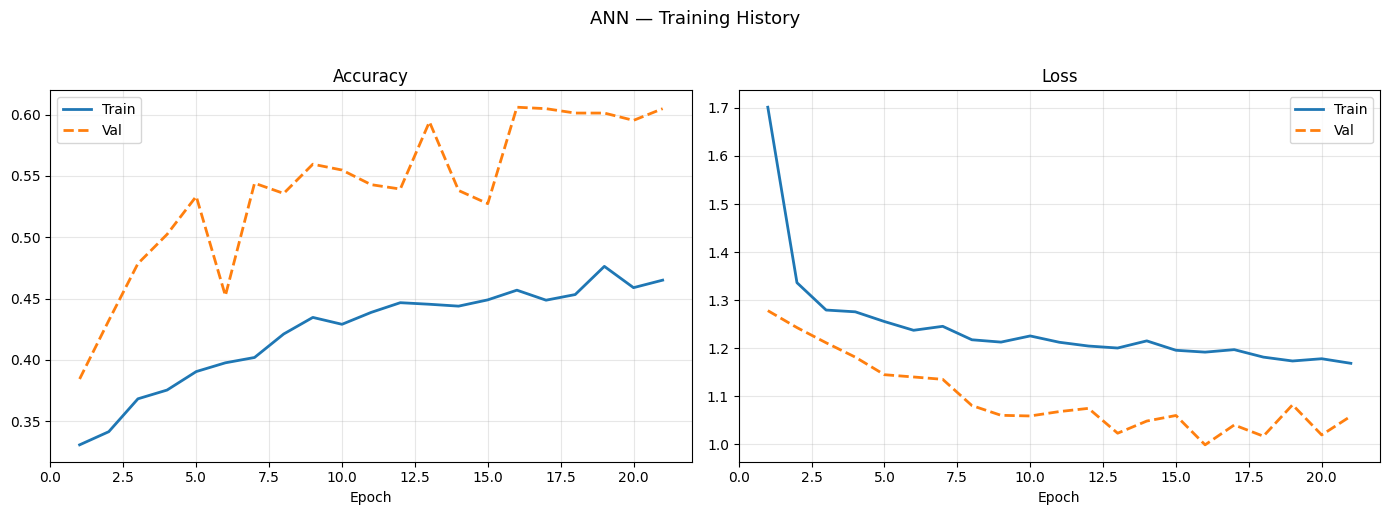

In [8]:
ann_history = ann_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss')],
    verbose=1,
)
plot_history(ann_history, 'ANN — Training History')


ANN — Test Accuracy: 0.5964 | Loss: 1.0124
              precision    recall  f1-score   support

      glioma     0.5016    0.7619    0.6049       210
  meningioma     0.6364    0.1667    0.2642       210
     notumor     0.8231    0.5762    0.6779       210
   pituitary     0.5799    0.8810    0.6994       210

    accuracy                         0.5964       840
   macro avg     0.6352    0.5964    0.5616       840
weighted avg     0.6352    0.5964    0.5616       840



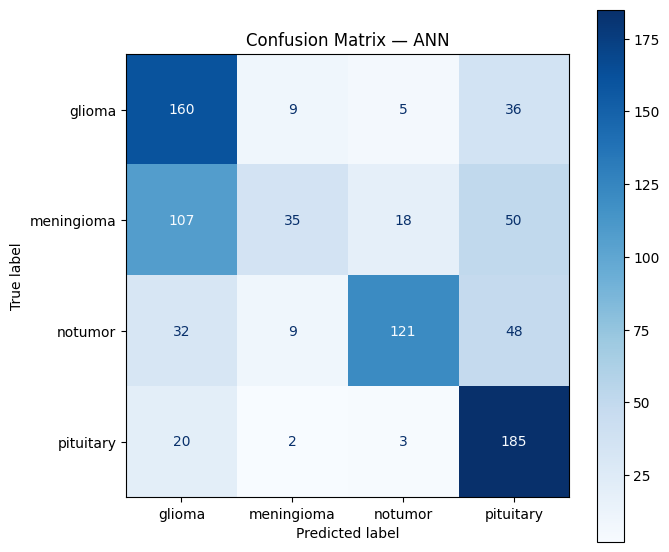

ANN saved.


In [9]:
ann_acc, ann_probs, ann_ytrue, ann_ypred = evaluate_model(ann_model, test_gen, 'ANN')
ann_model.save(str(DRIVE_DIR / 'ann_model.keras'))
print('ANN saved.')

## 2. Improved CNN Architecture

The improved CNN addresses the key weaknesses of the baseline:

| Hyperparameter | Baseline (Part 1) | Improved | Justification |
|----------------|------------------|----------|--------------|
| Conv blocks | 3 | 4 | Deeper feature hierarchy |
| Filters | 32→64→128 | 32→64→128→256 | Richer semantic representations |
| Normalisation | None | BatchNorm | Faster, more stable training |
| Regularisation | None | Dropout(0.4) | Prevents co-adaptation of neurons |
| Pooling head | Flatten | GlobalAvgPool | Fewer parameters, better generalisation |
| Learning rate | 0.001 (Adamax) | 0.0005 (Adam) | Finer gradient steps |
| Epochs | 20 | 30 | Fuller convergence with early stopping |
| Class weights | No | Yes | Addresses meningioma underrepresentation |

In [10]:
def build_improved_cnn(lr=5e-4, dropout=0.4, name='improved_cnn'):
    model = models.Sequential(name=name)
    for filters in [32, 64, 128, 256]:
        model.add(layers.Conv2D(filters, (3, 3), padding='same', use_bias=False,
                                input_shape=(224, 224, 3) if filters == 32 else ()))
        model.add(layers.BatchNormalization())
        model.add(layers.Activation('relu'))
        model.add(layers.MaxPooling2D(2, 2))
    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dropout(dropout))
    model.add(layers.Dense(4, activation='softmax'))
    model.compile(optimizer=tf.keras.optimizers.Adam(lr),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

print('build_improved_cnn defined.')

build_improved_cnn defined.


## 3. CNN Experiment A — Augmentation + Regularisation + Class Weights

Trains on standard (non-segmented) augmented images. Dropout (Srivastava et al., 2014) and BatchNormalization reduce overfitting. Class weights correct for meningioma's underrepresentation.

In [11]:
cnn_expA = build_improved_cnn(lr=5e-4, dropout=0.4, name='cnn_expA')
cnn_expA.summary()

Model: "cnn_expA"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 456,676 (1.74 MB)

 Trainable params: 455,716 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 77s 531ms/step - accuracy: 0.6648 - loss: 0.8300 - val_accuracy: 0.2667 - val_loss: 1.7386 - learning_rate: 5.0000e-04
Epoch 2/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 56s 459ms/step - accuracy: 0.7332 - loss: 0.6691 - val_accuracy: 0.4321 - val_loss: 1.9312 - learning_rate: 5.0000e-04
Epoch 3/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 56s 452ms/step - accuracy: 0.7679 - loss: 0.5950 - val_accuracy: 0.2393 - val_loss: 2.5670 - learning_rate: 5.0000e-04
Epoch 4/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.7978 - loss: 0.5435
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
123/123 ━━━━━━━━━━━━━━━━━━━━ 55s 448ms/step - accuracy: 0.8051 - loss: 0.5201 - val_accuracy: 0.2857 - val_loss: 2.0352 - learning_rate: 5.0000e-04
Epoch 5/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 56s 453ms/step - accuracy: 0.8324 - loss: 0.4471 - val_accuracy: 0.6631 - val_loss: 0.7591 - learning_rate: 2.5000e-04
Epoch 6/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 54s 442ms/st

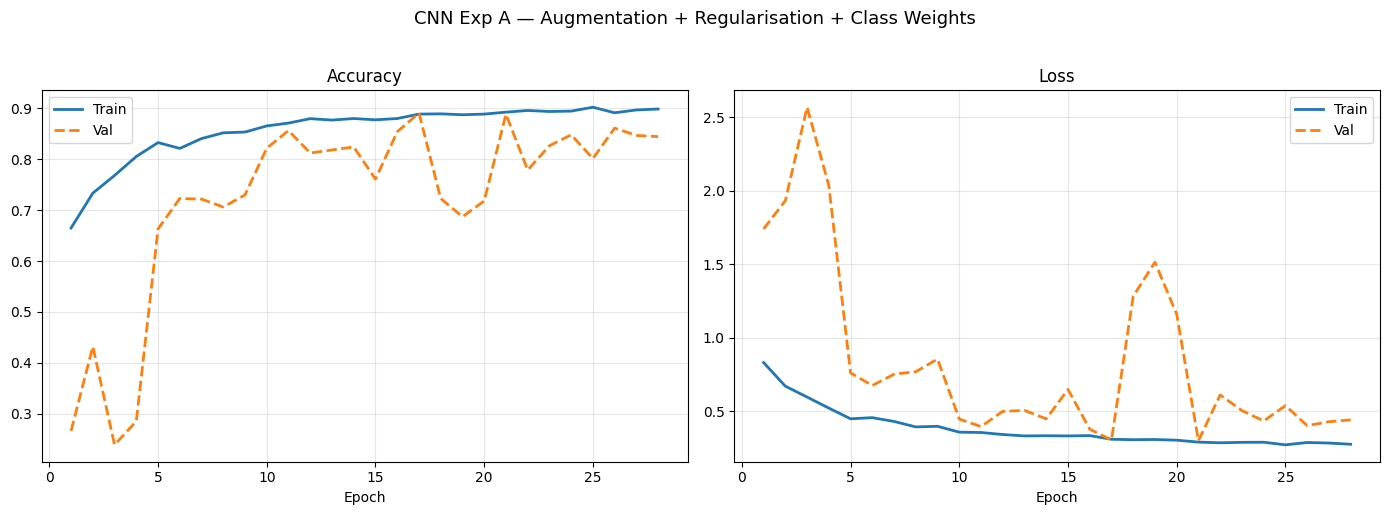

In [12]:
callbacks_A = [
    EarlyStopping(patience=7, restore_best_weights=True, monitor='val_loss'),
    ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint(str(DRIVE_DIR / 'cnn_expA_best.keras'), save_best_only=True, monitor='val_loss'),
]

histA = cnn_expA.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    class_weight=class_weight_dict,
    callbacks=callbacks_A,
    verbose=1,
)
plot_history(histA, 'CNN Exp A — Augmentation + Regularisation + Class Weights')


CNN Exp A — Test Accuracy: 0.8810 | Loss: 0.2985
              precision    recall  f1-score   support

      glioma     0.9087    0.9000    0.9043       210
  meningioma     0.7700    0.7810    0.7754       210
     notumor     0.9276    0.9762    0.9513       210
   pituitary     0.9192    0.8667    0.8922       210

    accuracy                         0.8810       840
   macro avg     0.8814    0.8810    0.8808       840
weighted avg     0.8814    0.8810    0.8808       840



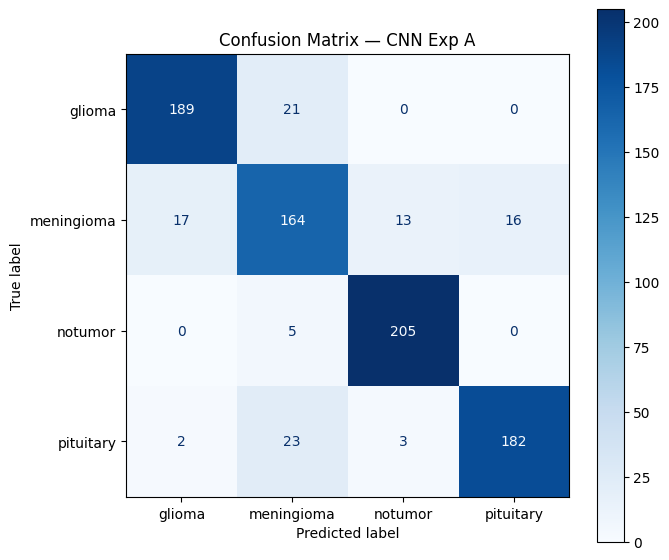

In [13]:
cnn_expA = tf.keras.models.load_model(str(DRIVE_DIR / 'cnn_expA_best.keras'))
accA, probsA, ytrue, ypredA = evaluate_model(cnn_expA, test_gen, 'CNN Exp A')

## 4. CNN Experiment B — Otsu Segmentation + Alternative Hyperparameters

**What changes from Exp A:**

| Hyperparameter | Exp A | Exp B |
|----------------|-------|-------|
| Learning rate | 5e-4 | 1e-3 |
| Dropout | 0.4 | 0.3 |
| Input preprocessing | Augmentation only | Otsu segmentation + augmentation |

Otsu segmentation removes skull and background, potentially reducing spurious feature activations.

Epoch 1/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 71s 522ms/step - accuracy: 0.6319 - loss: 0.8976 - val_accuracy: 0.2690 - val_loss: 2.2521 - learning_rate: 0.0010
Epoch 2/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 61s 497ms/step - accuracy: 0.7179 - loss: 0.7261 - val_accuracy: 0.2631 - val_loss: 2.9634 - learning_rate: 0.0010
Epoch 3/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 61s 491ms/step - accuracy: 0.7597 - loss: 0.6246 - val_accuracy: 0.4810 - val_loss: 1.6970 - learning_rate: 0.0010
Epoch 4/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 61s 496ms/step - accuracy: 0.7804 - loss: 0.5875 - val_accuracy: 0.5524 - val_loss: 1.5732 - learning_rate: 0.0010
Epoch 5/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 61s 495ms/step - accuracy: 0.8020 - loss: 0.5286 - val_accuracy: 0.5405 - val_loss: 1.4002 - learning_rate: 0.0010
Epoch 6/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 61s 495ms/step - accuracy: 0.8125 - loss: 0.5002 - val_accuracy: 0.7202 - val_loss: 0.6450 - learning_rate: 0.0010
Epoch 7/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 62s 498ms/step - accuracy: 0.8

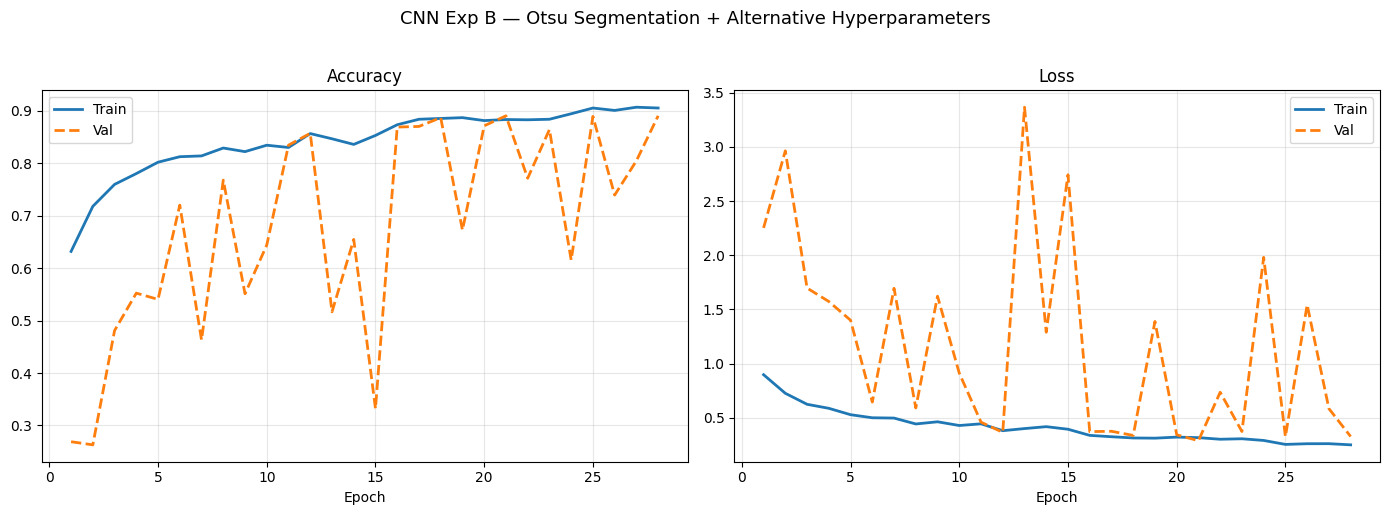

In [14]:
cnn_expB = build_improved_cnn(lr=1e-3, dropout=0.3, name='cnn_expB')

callbacks_B = [
    EarlyStopping(patience=7, restore_best_weights=True, monitor='val_loss'),
    ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint(str(DRIVE_DIR / 'cnn_expB_best.keras'), save_best_only=True, monitor='val_loss'),
]

histB = cnn_expB.fit(
    seg_train_gen,
    validation_data=seg_val_gen,
    epochs=30,
    class_weight=class_weight_dict,
    callbacks=callbacks_B,
    verbose=1,
)
plot_history(histB, 'CNN Exp B — Otsu Segmentation + Alternative Hyperparameters')


CNN Exp B (Otsu) — Test Accuracy: 0.8690 | Loss: 0.3043
              precision    recall  f1-score   support

      glioma     0.9822    0.7905    0.8760       210
  meningioma     0.7020    0.8524    0.7699       210
     notumor     0.9144    0.9667    0.9398       210
   pituitary     0.9381    0.8667    0.9010       210

    accuracy                         0.8690       840
   macro avg     0.8842    0.8690    0.8717       840
weighted avg     0.8842    0.8690    0.8717       840



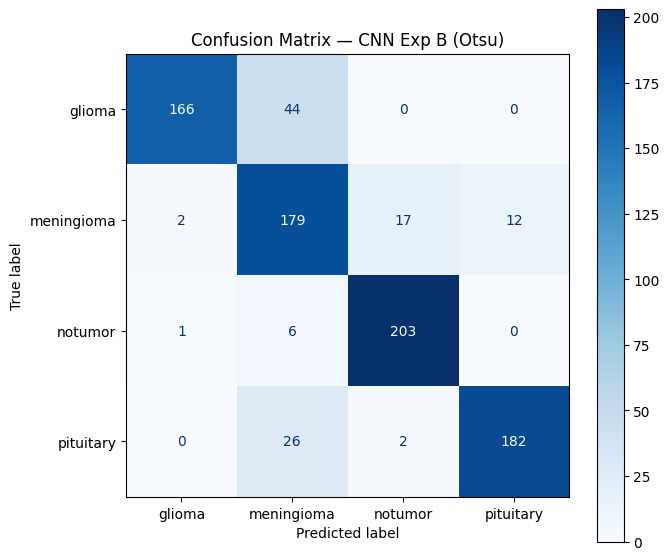

In [15]:
cnn_expB = tf.keras.models.load_model(str(DRIVE_DIR / 'cnn_expB_best.keras'))
accB, probsB, ytrue_seg, ypredB = evaluate_model(cnn_expB, seg_test_gen, 'CNN Exp B (Otsu)')

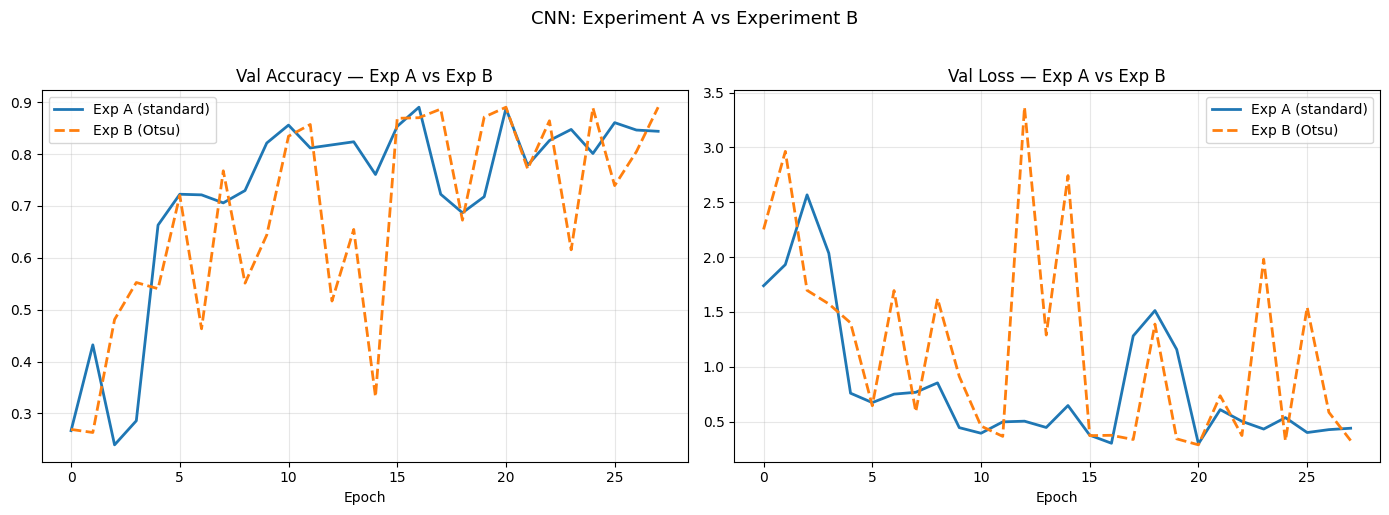

In [16]:
# Overlay validation curves: Exp A vs Exp B
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(histA.history['val_accuracy'], label='Exp A (standard)', linewidth=2)
ax1.plot(histB.history['val_accuracy'], label='Exp B (Otsu)', linewidth=2, linestyle='--')
ax1.set_title('Val Accuracy — Exp A vs Exp B'); ax1.set_xlabel('Epoch')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(histA.history['val_loss'], label='Exp A (standard)', linewidth=2)
ax2.plot(histB.history['val_loss'], label='Exp B (Otsu)', linewidth=2, linestyle='--')
ax2.set_title('Val Loss — Exp A vs Exp B'); ax2.set_xlabel('Epoch')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('CNN: Experiment A vs Experiment B', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 5. Summary — ANN vs CNN

              Accuracy  Macro F1
Baseline CNN    0.8286    0.8224
ANN             0.5964    0.5616
CNN Exp A       0.8810    0.8808
CNN Exp B       0.8690    0.8717


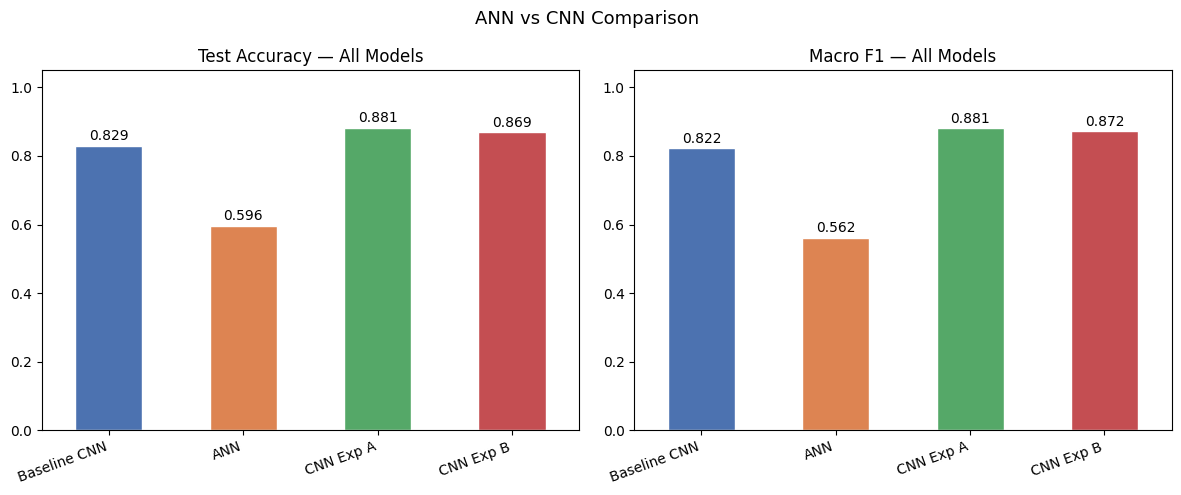

In [17]:
# Summary bar chart
from sklearn.metrics import classification_report as cr

def macro_f1(y_true, y_pred):
    r = cr(y_true, y_pred, output_dict=True)
    return r['macro avg']['f1-score']

summary = {
    'Baseline CNN': {'Accuracy': baseline_acc, 'Macro F1': macro_f1(ann_ytrue, np.argmax(baseline_model.predict(test_gen, verbose=0), 1))},
    'ANN':          {'Accuracy': ann_acc,      'Macro F1': macro_f1(ann_ytrue, ann_ypred)},
    'CNN Exp A':    {'Accuracy': accA,         'Macro F1': macro_f1(ytrue, ypredA)},
    'CNN Exp B':    {'Accuracy': accB,         'Macro F1': macro_f1(ytrue_seg, ypredB)},
}

summary_df = pd.DataFrame(summary).T
print(summary_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colours = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
summary_df['Accuracy'].plot.bar(ax=axes[0], color=colours, edgecolor='white')
axes[0].set_title('Test Accuracy — All Models'); axes[0].set_ylim(0, 1.05)
axes[0].bar_label(axes[0].containers[0], fmt='%.3f', padding=2)

summary_df['Macro F1'].plot.bar(ax=axes[1], color=colours, edgecolor='white')
axes[1].set_title('Macro F1 — All Models'); axes[1].set_ylim(0, 1.05)
axes[1].bar_label(axes[1].containers[0], fmt='%.3f', padding=2)

for ax in axes:
    ax.set_xlabel('')
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right')

plt.suptitle('ANN vs CNN Comparison', fontsize=13)
plt.tight_layout()
plt.show()